# Module 2 — Exploratory Data Analysis
Fraud detection on PaySim + synthetic contextual layer (`transactions_enriched.parquet`).

**Goals (per rubric):** quantify class imbalance; compare fraud rates across
transaction types and time; analyse distributions, outliers and correlations;
and visualise fraud patterns (amount, the balance "tell", geo/device signals).

In [1]:
import sys
from pathlib import Path
# robust path setup: works whether cwd is repo root or notebooks/
here = Path.cwd()
root = here if (here / "src").exists() else here.parent
sys.path.insert(0, str(root / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config import ENRICHED_DATA_PATH, FIGURES

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

df = pd.read_parquet(ENRICHED_DATA_PATH)
print(f"{len(df):,} rows x {df.shape[1]} columns")

6,362,620 rows x 23 columns


## 1. Data integrity

In [2]:
df.info()
print("\nmissing values:", int(df.isna().sum().sum()))
print("duplicate rows:", int(df.duplicated().sum()))

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 23 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   step                       int64  
 1   type                       str    
 2   amount                     float64
 3   nameOrig                   str    
 4   oldbalanceOrg              float64
 5   newbalanceOrig             float64
 6   nameDest                   str    
 7   oldbalanceDest             float64
 8   newbalanceDest             float64
 9   isFraud                    int64  
 10  isFlaggedFraud             int64  
 11  account_age_days           int64  
 12  home_billing_country       str    
 13  home_device_id             str    
 14  device_id                  str    
 15  is_new_device              int64  
 16  browser_fingerprint        str    
 17  shipping_billing_mismatch  int64  
 18  failed_payment_attempts    int64  
 19  ip_country                 str    
 20  ip_billing_di

## 2. Class imbalance — stated properly
The single most important number in the project. (The earlier notebook's
`value_counts(normalize=True)` was hidden by float formatting — here it is raw.)

In [3]:
n = len(df)
n_fraud = int(df["isFraud"].sum())
print(f"Total transactions : {n:,}")
print(f"Fraud transactions : {n_fraud:,}")
print(f"Fraud rate         : {n_fraud/n*100:.4f}%  (~1 in {n//max(n_fraud,1):,})")
print(f"Imbalance ratio    : {(n-n_fraud)/max(n_fraud,1):,.0f} legit : 1 fraud")

Total transactions : 6,362,620
Fraud transactions : 8,213
Fraud rate         : 0.1291%  (~1 in 774)
Imbalance ratio    : 774 legit : 1 fraud


## 3. Fraud by transaction type
Fraud is concentrated entirely in `TRANSFER` and `CASH_OUT`; the other types
never contain fraud. This justifies scoping features/modelling to those types.

,transactions,fraud,fraud_rate_pct,fraud_share_pct
type,,,,
TRANSFER,532909,4097,0.7688,49.8843
CASH_OUT,2237500,4116,0.1840,50.1157
CASH_IN,1399284,0,0.0000,0.0000
DEBIT,41432,0,0.0000,0.0000
PAYMENT,2151495,0,0.0000,0.0000


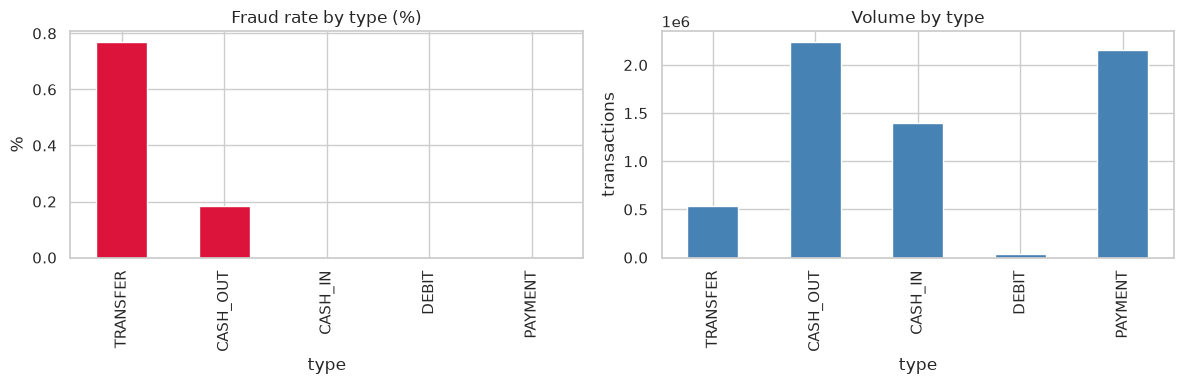

In [4]:
by_type = (df.groupby("type")
             .agg(transactions=("isFraud", "size"),
                  fraud=("isFraud", "sum"),
                  fraud_rate_pct=("isFraud", lambda s: s.mean()*100))
             .sort_values("fraud_rate_pct", ascending=False))
by_type["fraud_share_pct"] = by_type["fraud"] / by_type["fraud"].sum() * 100
display(by_type)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
by_type["fraud_rate_pct"].plot.bar(ax=ax[0], color="crimson")
ax[0].set_title("Fraud rate by type (%)"); ax[0].set_ylabel("%")
by_type["transactions"].plot.bar(ax=ax[1], color="steelblue")
ax[1].set_title("Volume by type"); ax[1].set_ylabel("transactions")
plt.tight_layout(); plt.savefig(FIGURES/"fraud_by_type.png", dpi=150, bbox_inches="tight"); plt.show()

## 4. Transaction amount — distribution and split by class
Amount is highly right-skewed, so we work on `log1p`. The key question is
whether fraud sits at different amounts than legit traffic.

/tmp/ipykernel_70273/3493520429.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[1].set_xticklabels(["legit", "fraud"]); ax[1].set_title("log(amount+1) by class")


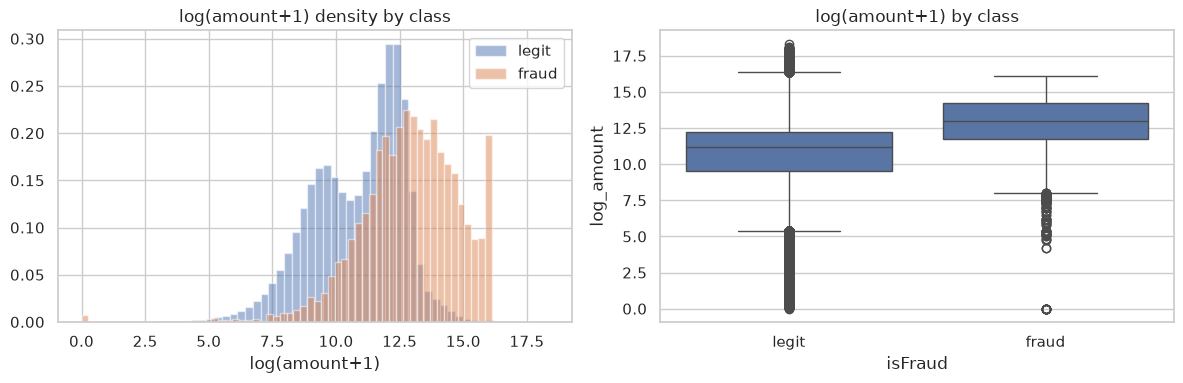

amount_decile
0   0.0233
1   0.0201
2   0.0233
3   0.0574
4   0.0970
5   0.0930
6   0.0913
7   0.0791
8   0.1130
9   0.6934
Name: fraud_rate_pct, dtype: float64

In [5]:
df["log_amount"] = np.log1p(df["amount"])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for label, sub in df.groupby("isFraud"):
    ax[0].hist(sub["log_amount"], bins=60, density=True, alpha=0.5,
               label=("fraud" if label else "legit"))
ax[0].set_title("log(amount+1) density by class"); ax[0].set_xlabel("log(amount+1)"); ax[0].legend()

sns.boxplot(data=df, x="isFraud", y="log_amount", ax=ax[1])
ax[1].set_xticklabels(["legit", "fraud"]); ax[1].set_title("log(amount+1) by class")
plt.tight_layout(); plt.savefig(FIGURES/"amount_by_class.png", dpi=150, bbox_inches="tight"); plt.show()

# fraud rate across amount deciles
df["amount_decile"] = pd.qcut(df["amount"], 10, labels=False, duplicates="drop")
display(df.groupby("amount_decile")["isFraud"].mean().mul(100).round(4).rename("fraud_rate_pct"))

## 5. The balance "tell" — strongest raw signal
In PaySim, fraud drains the origin account. We build two consistency-error
features and inspect them by class:

- `errorBalanceOrig = oldbalanceOrg - amount - newbalanceOrig`
- `errorBalanceDest = oldbalanceDest + amount - newbalanceDest`

In [6]:
df["errorBalanceOrig"] = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]
df["origin_emptied"] = ((df["newbalanceOrig"] == 0) &
                        (np.isclose(df["oldbalanceOrg"], df["amount"]))).astype(int)

print("mean error-balance by class:")
display(df.groupby("isFraud")[["errorBalanceOrig", "errorBalanceDest"]].mean())
print("\nP(origin fully emptied) by class:")
display(df.groupby("isFraud")["origin_emptied"].mean())

mean error-balance by class:


,errorBalanceOrig,errorBalanceDest
isFraud,,
0,"-201,338.5581","54,692.2317"
1,"-10,692.3253","732,509.3011"



P(origin fully emptied) by class:


isFraud
0   0.0000
1   0.9770
Name: origin_emptied, dtype: float64

## 6. Time-of-day pattern
`hour_of_day` is derived from `step` (`step % 24`). We compare fraud **rate** by
hour rather than counts, since volume varies through the day.

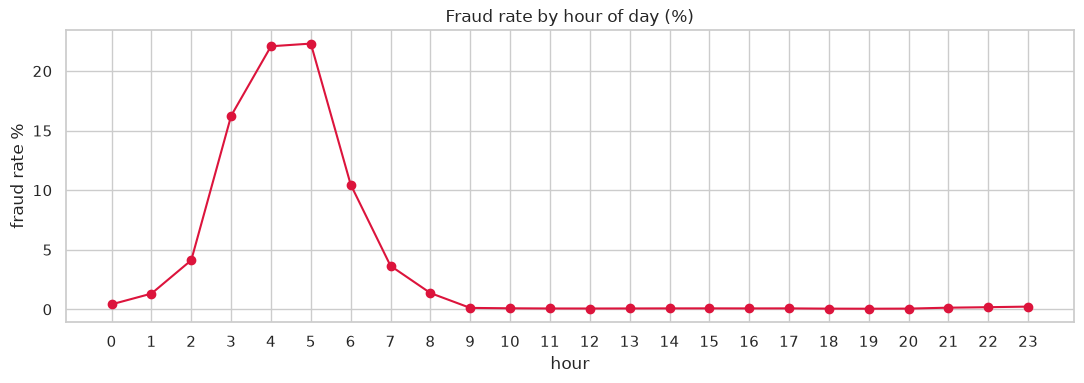

In [7]:
hourly = df.groupby("hour_of_day")["isFraud"].mean().mul(100)
plt.figure(figsize=(11, 4))
hourly.plot(marker="o", color="crimson")
plt.title("Fraud rate by hour of day (%)"); plt.xlabel("hour"); plt.ylabel("fraud rate %")
plt.xticks(range(0, 24)); plt.tight_layout()
plt.savefig(FIGURES/"fraud_by_hour.png", dpi=150, bbox_inches="tight"); plt.show()

## 7. Synthetic contextual signals vs fraud
Each engineered contextual signal should show a clear but non-perfect lift for
fraud — real signal, no leakage.

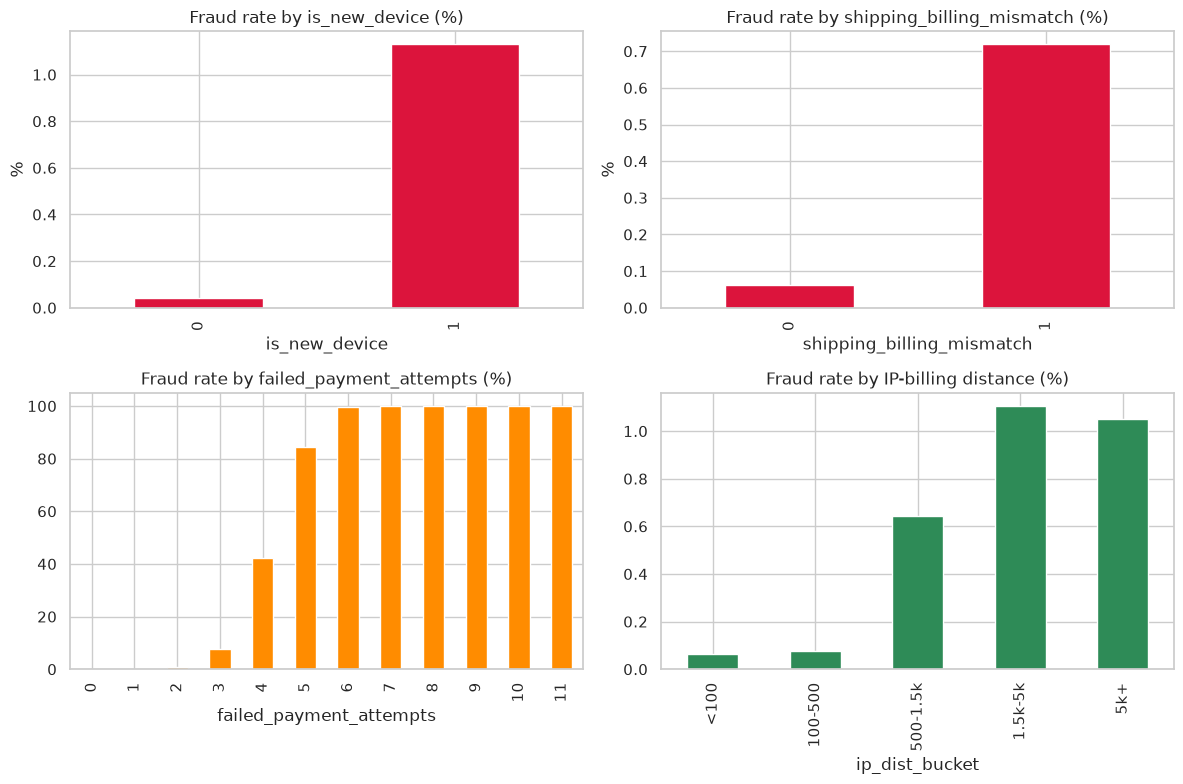

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# binary flags -> fraud rate
for a, col in zip(ax[0], ["is_new_device", "shipping_billing_mismatch"]):
    df.groupby(col)["isFraud"].mean().mul(100).plot.bar(ax=a, color="crimson")
    a.set_title(f"Fraud rate by {col} (%)"); a.set_ylabel("%")

# failed attempts -> fraud rate
df.groupby("failed_payment_attempts")["isFraud"].mean().mul(100).plot.bar(
    ax=ax[1][0], color="darkorange")
ax[1][0].set_title("Fraud rate by failed_payment_attempts (%)")

# ip distance buckets -> fraud rate
df["ip_dist_bucket"] = pd.cut(df["ip_billing_distance_km"],
                              [-1, 100, 500, 1500, 5000, 1e9],
                              labels=["<100", "100-500", "500-1.5k", "1.5k-5k", "5k+"])
df.groupby("ip_dist_bucket")["isFraud"].mean().mul(100).plot.bar(
    ax=ax[1][1], color="seagreen")
ax[1][1].set_title("Fraud rate by IP-billing distance (%)")
plt.tight_layout(); plt.savefig(FIGURES/"synthetic_signals.png", dpi=150, bbox_inches="tight"); plt.show()

## 8. Correlation with fraud (numeric features)

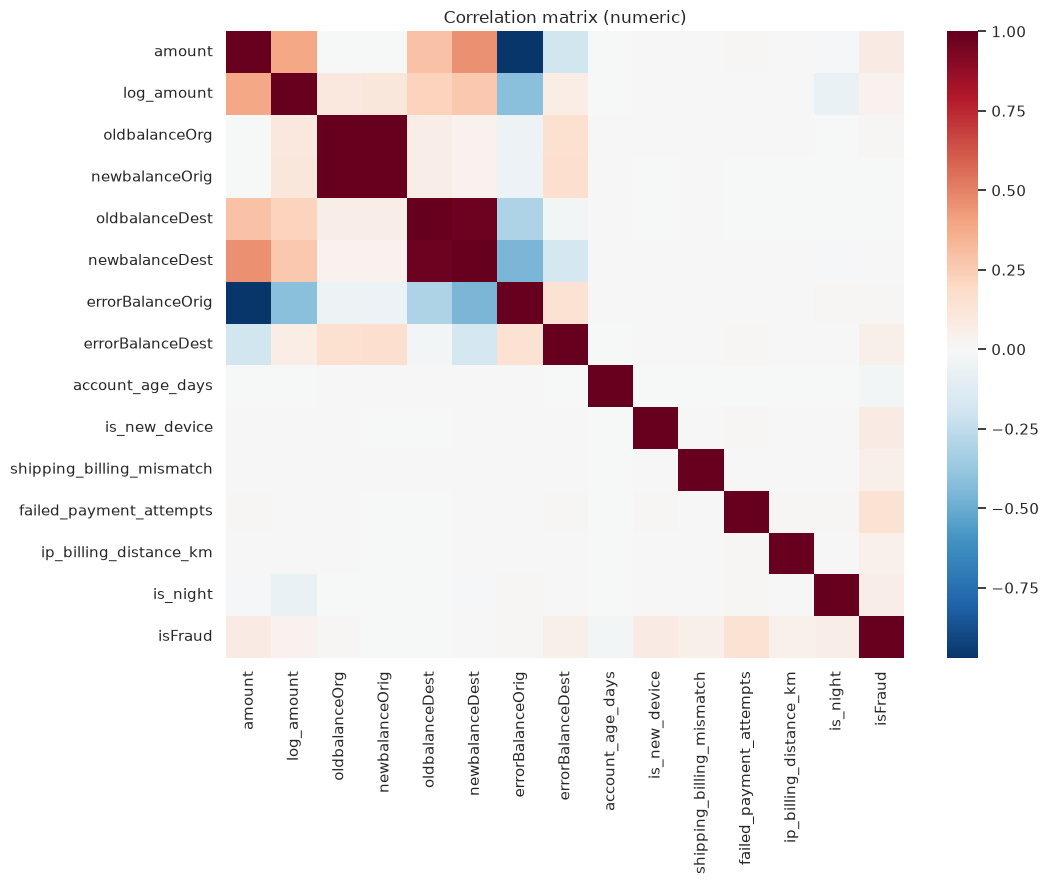

Correlation with isFraud (sorted):


failed_payment_attempts      0.1438
is_new_device                0.0825
amount                       0.0767
is_night                     0.0614
errorBalanceDest             0.0551
shipping_billing_mismatch    0.0549
ip_billing_distance_km       0.0496
log_amount                   0.0406
account_age_days            -0.0251
errorBalanceOrig             0.0113
oldbalanceOrg                0.0102
newbalanceOrig              -0.0081
oldbalanceDest              -0.0059
newbalanceDest               0.0005
Name: isFraud, dtype: float64

In [9]:
num = ["amount", "log_amount", "oldbalanceOrg", "newbalanceOrig",
       "oldbalanceDest", "newbalanceDest", "errorBalanceOrig", "errorBalanceDest",
       "account_age_days", "is_new_device", "shipping_billing_mismatch",
       "failed_payment_attempts", "ip_billing_distance_km", "is_night", "isFraud"]
corr = df[num].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False)
plt.title("Correlation matrix (numeric)")
plt.tight_layout(); plt.savefig(FIGURES/"correlation_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

print("Correlation with isFraud (sorted):")
display(corr["isFraud"].drop("isFraud").sort_values(key=np.abs, ascending=False))

## 9. Two documentation findings
- **`isFlaggedFraud` is near-useless** — PaySim's built-in rule flags almost
  nothing, so it carries no signal and is a candidate to drop.
- **Merchants (`nameDest` starting `M`) are never defrauded** — fraud only
  targets customer destinations.

In [10]:
print("isFlaggedFraud value counts:")
display(df["isFlaggedFraud"].value_counts())
print("fraud rate when isFlaggedFraud==1 vs 0:")
display(df.groupby("isFlaggedFraud")["isFraud"].mean())

df["dest_is_merchant"] = df["nameDest"].str.startswith("M").astype(int)
print("\nfraud rate by destination type (merchant vs customer):")
display(df.groupby("dest_is_merchant")["isFraud"].mean().mul(100).rename("fraud_rate_pct"))

isFlaggedFraud value counts:


isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

fraud rate when isFlaggedFraud==1 vs 0:


isFlaggedFraud
0   0.0013
1   1.0000
Name: isFraud, dtype: float64


fraud rate by destination type (merchant vs customer):


dest_is_merchant
0   0.1950
1   0.0000
Name: fraud_rate_pct, dtype: float64

## 10. EDA takeaways (feed into Modules 3–5)
1. **Extreme imbalance (~0.13%)** → use AUC-PR / precision-recall + a cost metric; resample only on the training fold.
2. **Fraud only in TRANSFER & CASH_OUT** → scope modelling to these; huge search-space reduction.
3. **Balance tell** (`errorBalanceOrig/Dest`, `origin_emptied`) is the strongest raw signal → keep as features.
4. **Synthetic signals** (new device, mismatch, failed attempts, IP distance, younger accounts) all lift fraud rate without leaking → keep.
5. **Drop `isFlaggedFraud`** (no signal). Consider restricting to non-merchant destinations.
6. **Amount is right-skewed** → use `log_amount`.